# Cycle 2: matching the post-shut-in stimulation

Habanero 4, November 2012. The clock is restarted at **data-day 4.300**, where
injection resumes after the first shut-in, and cycle 1 is discarded rather than
inherited. Twenty simulations: five initial shear stresses crossed with four
fluid parameterisations.

---

## Provenance and data handling

**No observational file has been modified.** The event catalogue, injection-rate
and wellhead-pressure files, the slip profiles and the injection deck all
predate this analysis; every transformation below lives in plotting code.

| file | md5 | last modified |
|---|---|---|
| `Cooper_Basin_Catalog_HAB_4.mat` | `04b7d43f…` | 2026-04-30 |
| `Cooper_Basin_HAB_4_Injection_Rate.mat` | `e3aca62c…` | 2026-04-30 |
| `Cooper_Basin_HAB_4_Wellhead_Pressure.mat` | `c1a7c737…` | 2026-04-30 |
| `slip_profiles_strike.txt` | `5c7b2249…` | 2025-12-02 |
| `june_clean.txt` | `603285de…` | 2026-06-26 |

**Seven transformations are applied to the observed series.** Three change the
appearance of the observed curve and are the ones to scrutinise:

1. **Time shift, −4.300 d.** Simulation *t* = 0 is data-day 4.300, so all
   observed series are pulled back by that amount to put both on one clock.
   Display only.
2. **Slip plotted as an increment.** 2.81 cm — the observed cumulative slip at
   *t*₀ — is subtracted. Required, not preferred: `main_LH.f90:923` sets
   `slip = 0d0` unconditionally, so HBI cannot carry pre-existing slip and
   absolute observed slip is not a quantity it can reproduce. **This makes the
   observed slip curve smaller than the raw record**, deliberately.
3. **The 87.76 MPa pressure transient is excluded** from the wellhead score and
   lies outside the plotted range. Two samples at data-day 14.23, 92% of the
   overburden stress, bracketed by a sustained ~48 MPa — consistent with
   water-hammer on valve actuation rather than reservoir pressure. Masked, not
   deleted.

The remaining four are methodological: the front is a running maximum rather
than a percentile; the full 20 735-event catalogue is used rather than the
17 574 inside the usual 13–30 November window; square-root fits carry a shifted
origin; envelopes are fitted by quantile.

In [1]:
import importlib.util as iu
from IPython.display import Image, display
CB = "/home/users/nberrios/3dhbi/hbi_git/docs/cooper_basin"
s = iu.spec_from_file_location("cc", CB + "/compare_cycle2.py")
cc = iu.module_from_spec(s); s.loader.exec_module(cc)
FIG = "/home/users/nberrios/3dhbi/hbi_analysis/figures"
print("figures produced by docs/cooper_basin/compare_cycle2.py")

figures produced by docs/cooper_basin/compare_cycle2.py


---

## Figure 1 — Five best-scoring simulations

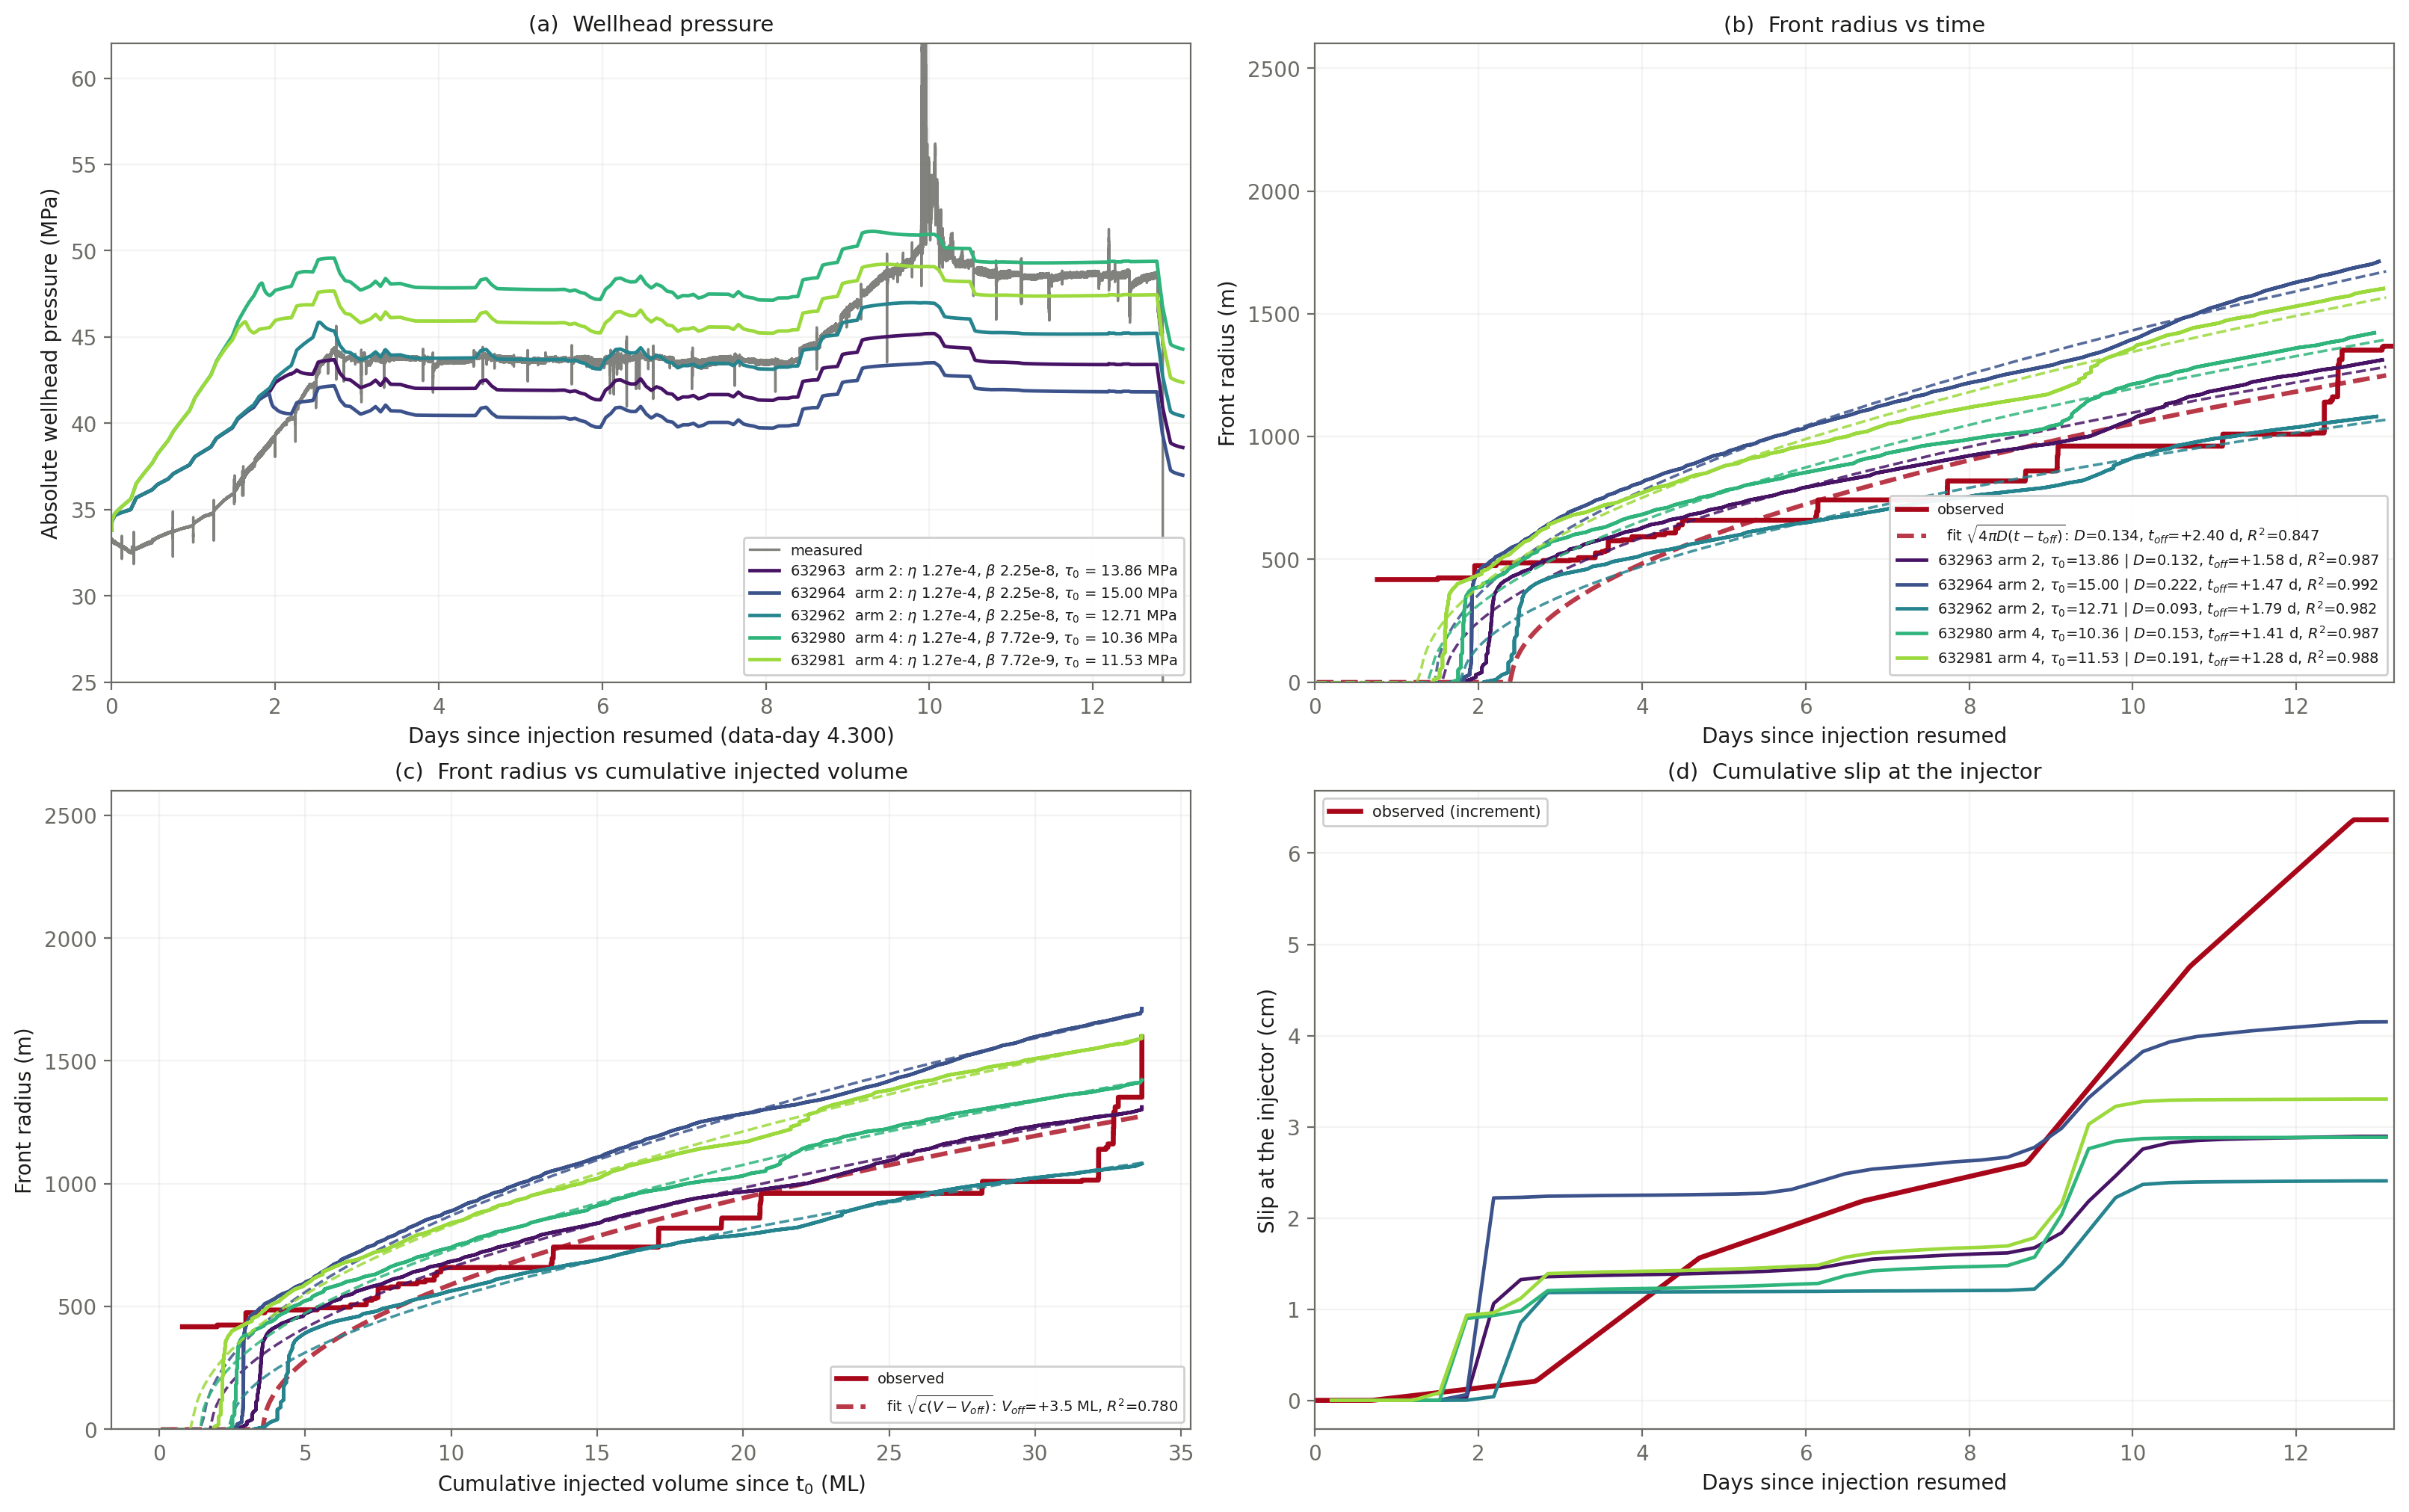

In [2]:
display(Image(filename=f"{FIG}/cycle2/cycle2_compare_top5.png"))

**Figure 1.** Post-shut-in comparison for the five best-scoring simulations of
twenty. All panels are on simulation time, whose origin is data-day 4.300; every
observed series (red, grey) is shifted back by that interval accordingly. Runs
are labelled by arm — arm 2 is η = 1.27×10⁻⁴ Pa·s with β = 2.25×10⁻⁸ Pa⁻¹,
arm 4 the same viscosity with β = 7.72×10⁻⁹ Pa⁻¹ — and by initial shear stress
τ₀.

*(a)* Absolute wellhead pressure. Grey is the measured record; its vertical
excursions are gauge noise. A two-sample transient reaching 87.76 MPa at
simulation *t* ≈ 10 d (data-day 14.23) lies above the plotted range: it is 92%
of the estimated overburden stress and is bracketed by a sustained ~48 MPa,
attributed to water-hammer on valve actuation and excluded from the pressure
score. All simulations begin near 33.8 MPa because the decks specify
`pfinit = 0`, zero initial overpressure; the measurement at *t*₀ is 33.27 MPa
against a pre-injection baseline of 34.41 MPa, so the reservoir is in fact drawn
down by ≈1.1 MPa following the 1.59–3.56 d bleed-off. The simulations therefore
begin ≈0.5 MPa high and, more consequentially, reach the 43.7 MPa plateau in
~2.5 d where the measurement requires ~4 d.

*(b)* Front radius against time. The observed front (red, solid) is the running
maximum of event distance from the injector over the full catalogue, monotone by
construction; a per-bin high percentile is not a front and retreats four times
on this catalogue. Dashed curves are least-squares fits of r² = 4πD(t − t_off),
the square-root law with its origin displaced. The displacement is not cosmetic:
the observed front already stands at ≈420 m when the clock restarts, so a fit
through r = 0, t = 0 would absorb that offset into D. Fitted D and the
coefficient of determination of the r²-versus-t regression appear in the legend;
the latter tests whether the square-root law holds at all.

*(c)* The same fronts against cumulative injected volume since *t*₀. Volume
absorbs the rate history, so the staircase visible in *(b)* — each step
coincident with a rate increase — is largely removed and the fits improve
accordingly, R² ≈ 0.99 against 0.98.

*(d)* Cumulative slip at the injector. The observed curve is the **increment**
since *t*₀: the seismicity-derived cumulative slip less its value of 2.81 cm at
data-day 4.300. Simulated slip rises in two steps, at *t* ≈ 2 d and *t* ≈ 9 d,
both following rate increases; the observed increment rises more smoothly and
overtakes every simulation after *t* ≈ 11 d.

---

## Figure 2 — Ten best-scoring simulations

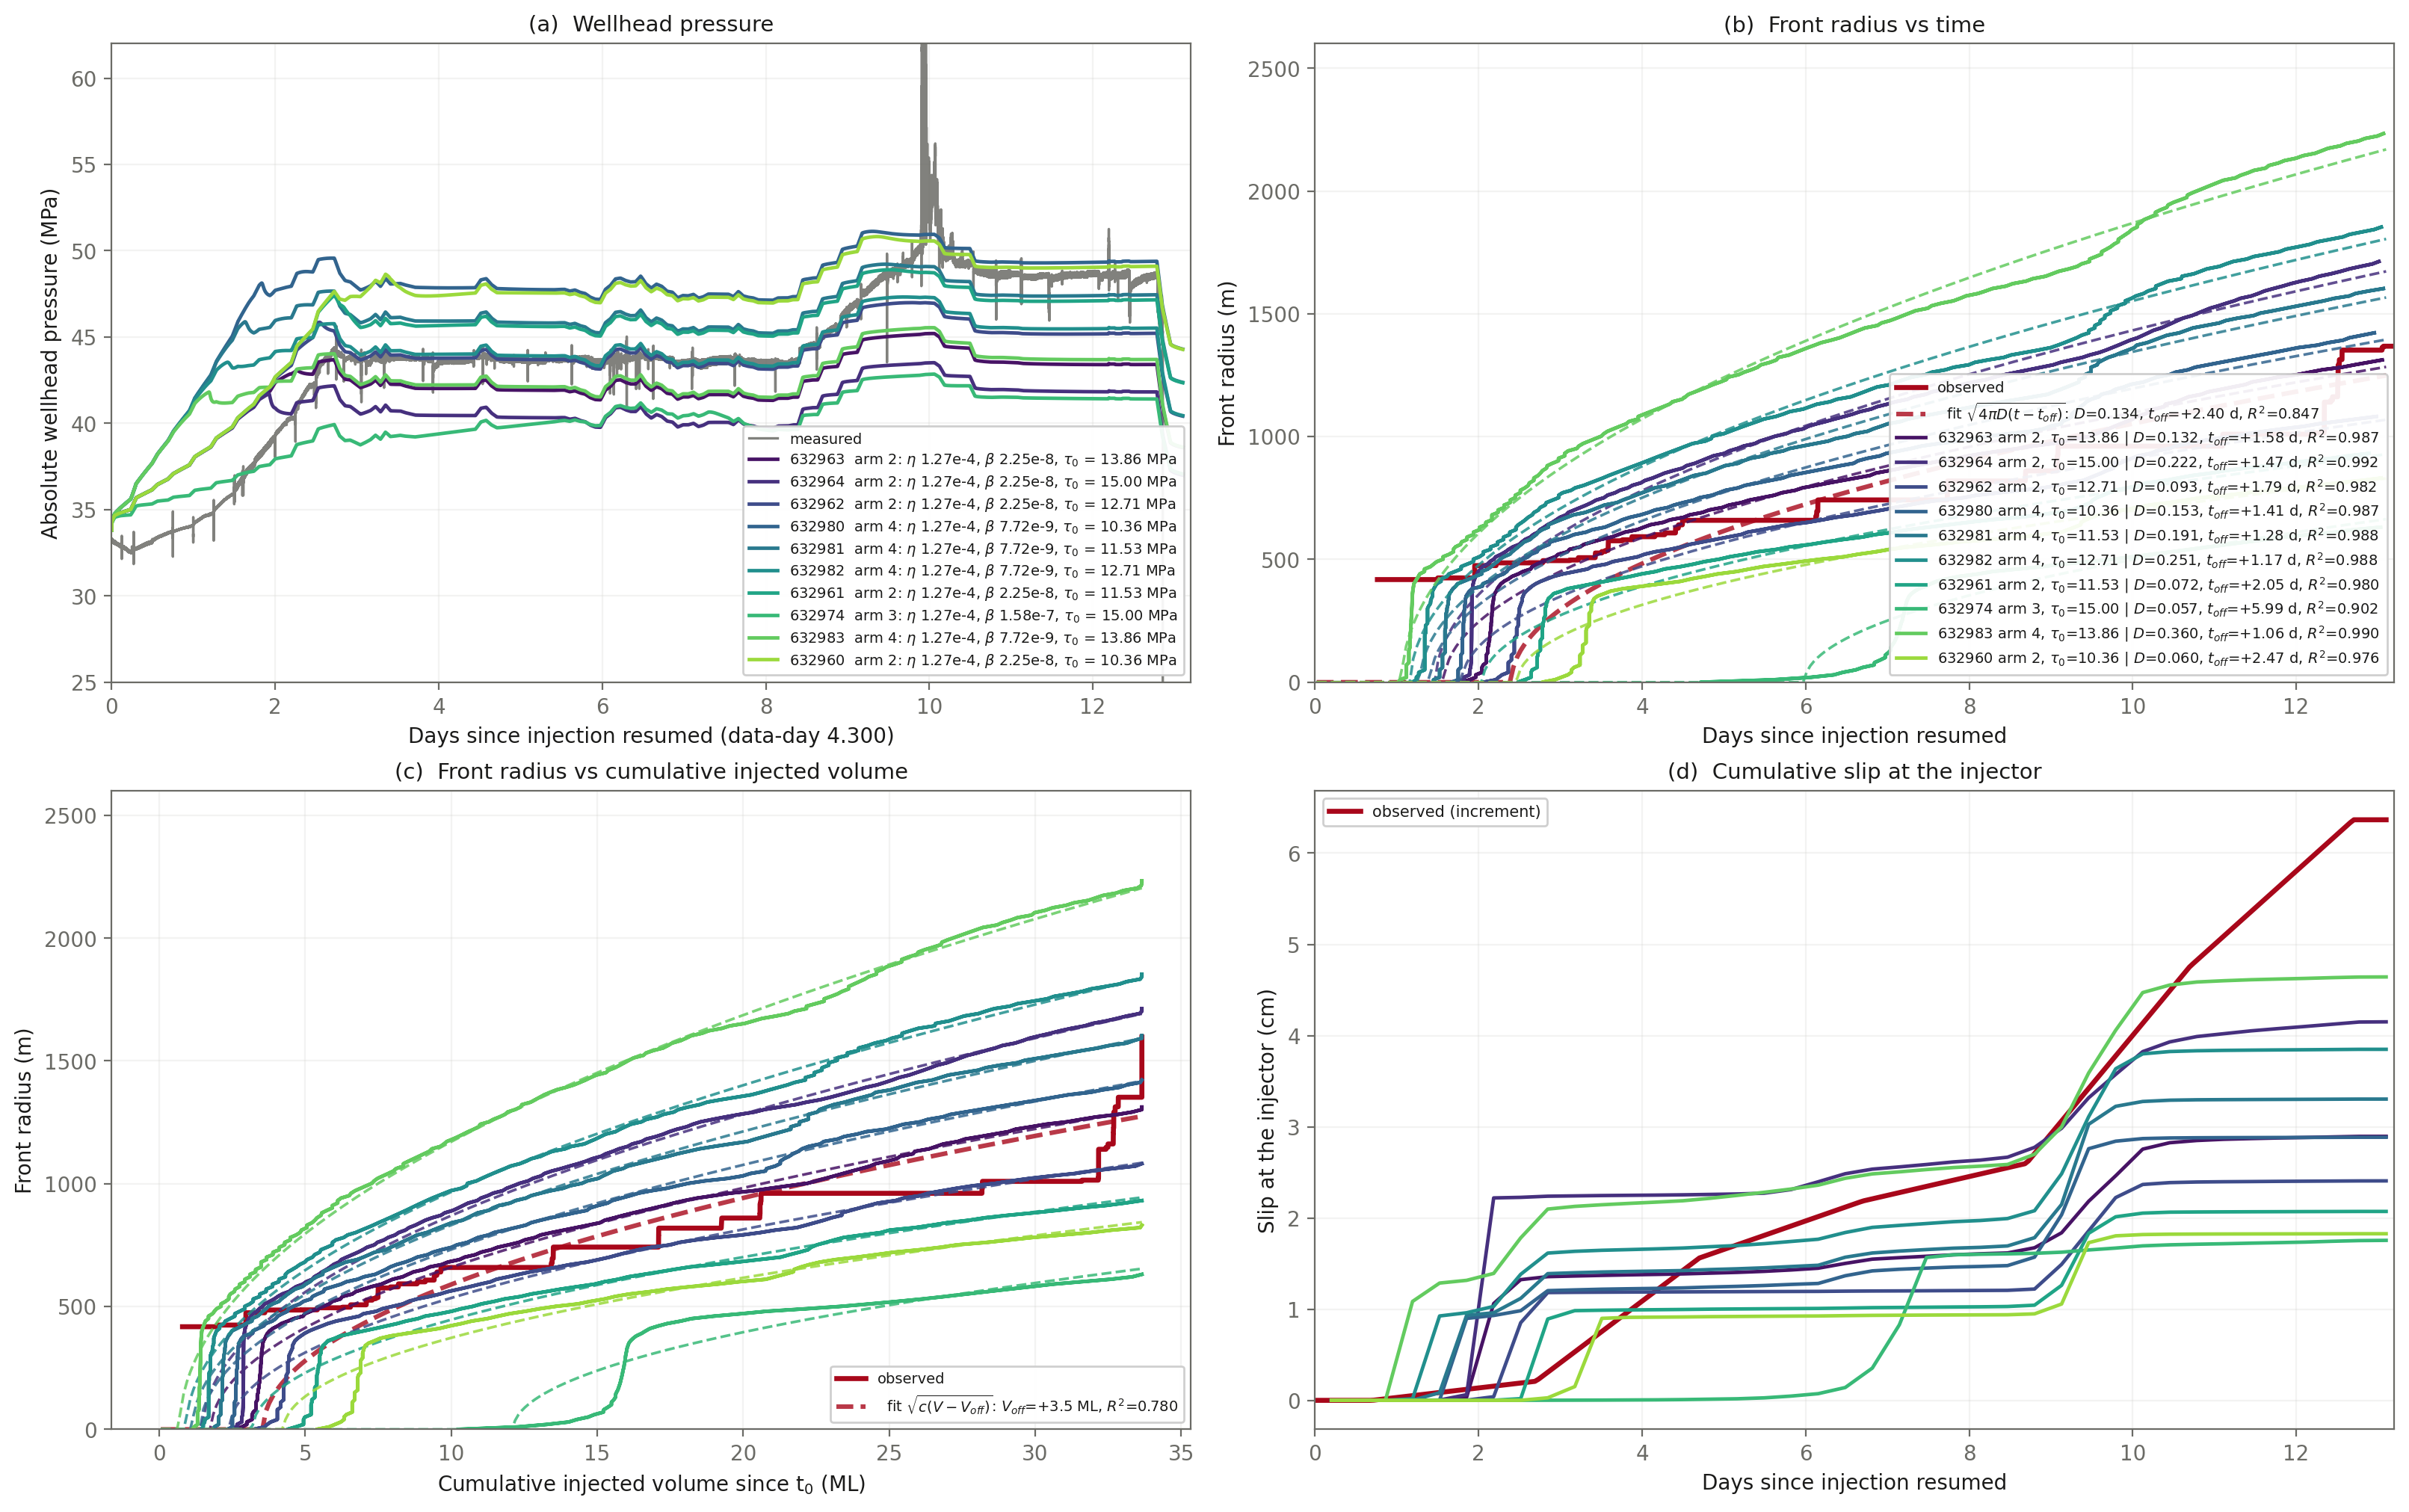

In [3]:
display(Image(filename=f"{FIG}/cycle2/cycle2_compare_top10.png"))

**Figure 2.** As Figure 1, for the ten best-scoring simulations. Ranking is by
|front/observed − 1| + |wellhead bias| + |slip/observed − 1|, evaluated at
simulation *t* = 8.7 d (data-day 13.0), where the observed front is 860 m and
the observed slip increment 2.598 cm.

The arms separate cleanly. Arm 1 (η = 8.9×10⁻⁴ Pa·s, the value used by Wang &
Dunham) does not appear among the ten: its wellhead bias is +43 to +55%, in
common with all eighty-six simulations of the preceding full-record study. Arms
2 and 4, both at η = 1.27×10⁻⁴ Pa·s appropriate to the reservoir's depth and
temperature, lie within a few percent of the measured pressure — arm 2 at
τ₀ = 12.71 MPa gives −1.0%. Since the amplitude of the pressure solution scales
linearly with viscosity, reducing η sevenfold reduces the overpressure by the
same factor, which is the correction the wellhead required.

Arm 3 (β = 1.58×10⁻⁷, chosen to hold the diffusivity at arm 1's value) is
represented by a single run and fails elsewhere: with seven times the storage it
produces no slip below τ₀ = 13.86 MPa. It is also the only parameterisation
requiring φβ = 1.58×10⁻⁹, a factor 3.94 above the range admitted by
φ ∈ [0.005, 0.02] and β ∈ [10⁻⁹, 2×10⁻⁸]. Matching the diffusivity at the
corrected viscosity and retaining a defensible compressibility are mutually
exclusive.

One discrepancy is common to all arms: simulated fronts do not depart from the
origin until *t* ≈ 1.0–2.5 d, whereas the observed front already stands at
420 m. The delay is the interval required for slip somewhere on the fault to
exceed the 10⁻⁴ m contour defining the front, and appears in the fits as
t_off = +1.1 to +2.5 d.

---

## Figure 3 — Triggering front and back front, full record

20734 events; 19276 after injection resumes (4.3 d), 2715 after shut-in (17.455 d)

TRIGGERING FRONT   r = sqrt(4 pi D t),  t from 4.3 d
  D = 0.1018 m^2/s  (95% of events below)  ->  k = 2.04e-14 m^2
  CONVENTION MATTERS: the same envelope under r = sqrt(4Dt) gives
  D = 0.3197 m^2/s, pi times larger. The 4 pi is one
  WAVELENGTH of the diffusion wave at omega ~ 2 pi/t, which Shapiro
  (2000) calls partly heuristic -- see the module docstring.
  [alternative, t from 0.501 d: D = 0.0803, a worse envelope]
BACK FRONT         r = sqrt(4 D t(t-t_s)/t_s ln(t/(t-t_s)))
  D = 0.1543 m^2/s  (5% of post-shut-in events below)  ->  k = 3.09e-14 m^2

ratio D_back/D_trig = 1.5x
model bounds: kpmin -> 0.0050, kpmax -> 1.248 m^2/s

PERMEABILITY DEPENDS ON WHICH VISCOSITY, k = D*eta*phi*beta:
  deck / Taiyi  eta = 0.89e-3:  k_trig = 2.04e-14,  k_back = 3.09e-14 m^2
  reservoir     eta = 1.27e-4:  k_trig = 2.91e-15,  k_back = 4.41e-15 m^2
  the D comparison above is eta-INDEPENDENT; only k is affected


wrote /home/users/nberrios/3dhbi/hbi_analysis/figures/postshutin/classic_front_fit.png


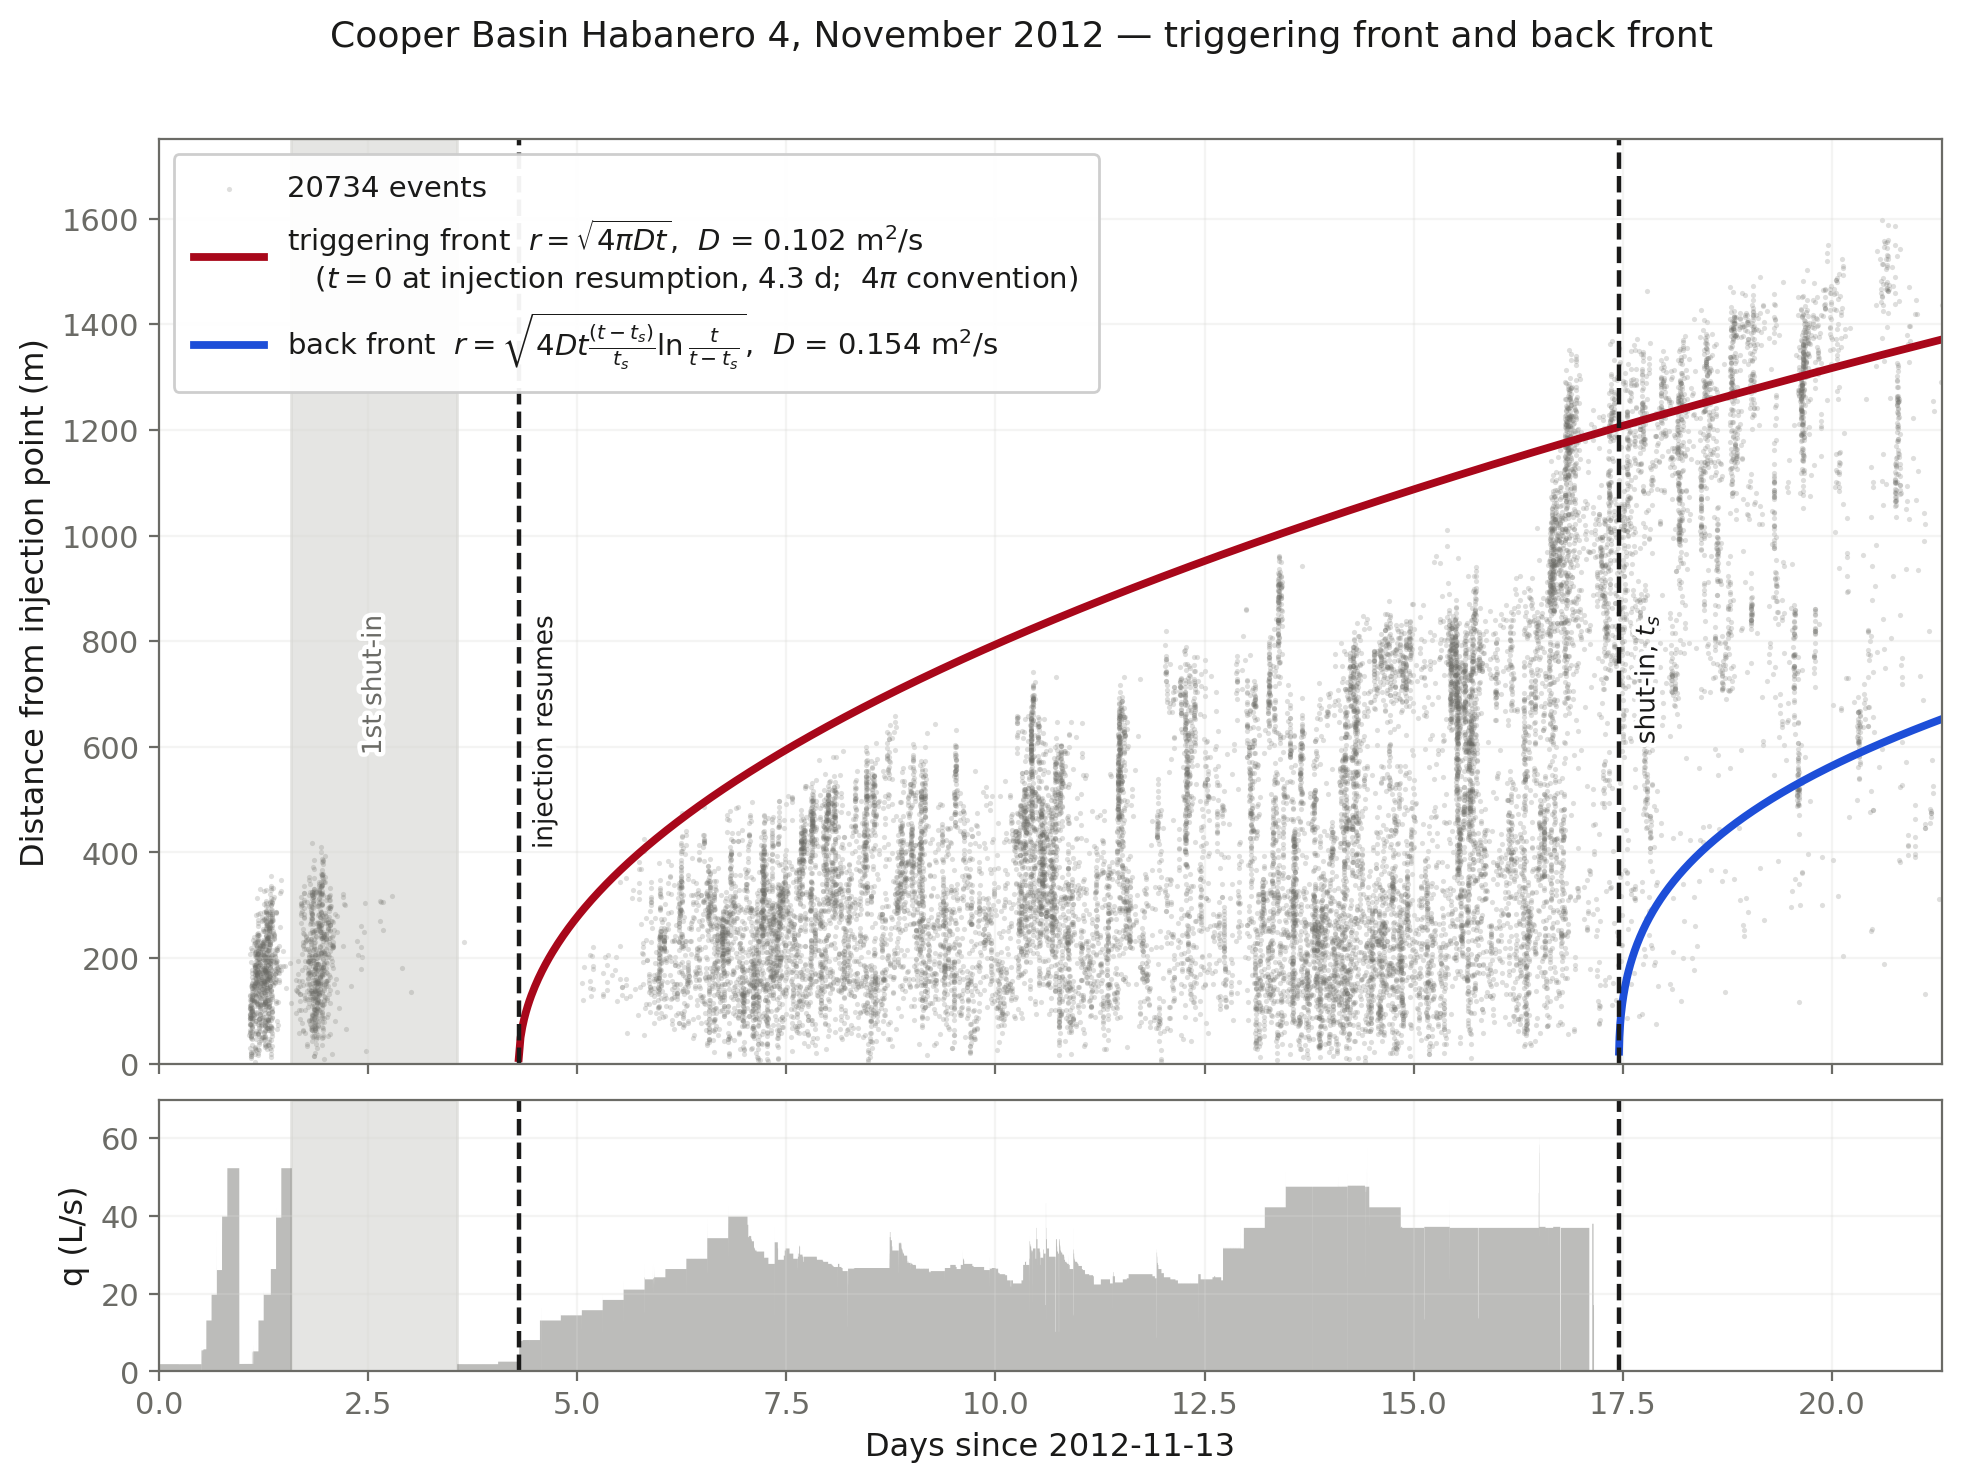

In [4]:
s2 = iu.spec_from_file_location(
    "cf", "/home/users/nberrios/3dhbi/hbi_git/docs/postshutin/classic_front_fit.py")
cf = iu.module_from_spec(s2); s2.loader.exec_module(cf)
D_trig, D_back = cf.main([])
display(Image(filename=f"{FIG}/postshutin/classic_front_fit.png"))

**Figure 3.** Distance from the injection point against time for all 20 734
located events of the November 2012 stimulation, with analytical envelopes.
Lower panel, injection rate.

The catalogue extends to 4 December, whereas the 13–30 November window used
elsewhere in this project retains 17 574 events. The 3 161 excluded are almost
entirely post-injection, which is where a back front is expressed; their
omission is why no back front had previously been identified in this dataset.

**Triggering front** (red), r = √(4πDt), fitted so that 95% of events fall below
it. The origin is taken at injection resumption, 4.300 d, rather than at first
injection: against the observed daily maximum the residual is 147 m for the
former and 207 m for the latter, with worst-case undershoots of 122 and 404 m,
because the formula presumes continuous injection and the record is interrupted
between 1.582 and 4.300 d. The factor 4π is not a derived constant. It follows
from identifying the front with one wavelength of the pore-pressure diffusion
wave, λ = 2πδ with skin depth δ = √(2D/ω), evaluated at the frequency
ω ≈ 2π/t characteristic of a step of duration t; Shapiro (2000, *Geophys. J.
Int.* **143**, 931) describes that frequency assignment as "of partially
heuristic character". D therefore scales inversely with the prefactor: the same
envelope fitted as r = √(4Dt) returns D = 0.320 m² s⁻¹ rather than 0.102, and no
diffusivity from a triggering front is meaningful without its convention.

**Back front** (blue), r = √(4Dt(t − t_s)/t_s · ln[t/(t − t_s)]), fitted so that
5% of post-shut-in events fall below it, t_s being the injection duration. This
prefactor *is* derived. A fault plane with a point injection is
two-dimensional radial, so the pressure kernel is the exponential integral
rather than the three-dimensional complementary error function; superposing an
injection from t = 0 with a withdrawal from t_s and imposing ∂p/∂t = 0 yields
the expression above, in agreement with Parotidis, Shapiro & Rothert (2004,
*Geophys. Res. Lett.* **31**, L02612). A three-dimensional point source would
give 6D in place of 4D.

The two diffusivities differ: 0.102 m² s⁻¹ during injection against
0.154 m² s⁻¹ after shut-in. Both are independent of any simulation. Inferring
permeability from them is *not* independent of viscosity, since k = Dηφβ, and
the two candidate values differ sevenfold: k = 2.0×10⁻¹⁴ and 3.1×10⁻¹⁴ m² at
η = 8.9×10⁻⁴ Pa·s, or 2.9×10⁻¹⁵ and 4.4×10⁻¹⁵ m² at η = 1.27×10⁻⁴. Both fall
between the background and enhanced permeabilities specified in the simulations,
10⁻¹⁵ and 2.5×10⁻¹³ m², so the model brackets the observation while spanning a
range some forty times wider than it supports.

---

## Summary

Evaluated at simulation *t* = 8.7 d (data-day 13.0). Front target 860 m;
wellhead bias relative to the measured record over flowing intervals; slip
target 2.598 cm as an increment since *t*₀.

| run | arm | τ₀ (MPa) | front | wellhead | slip |
|---|---|---|---|---|---|
| 632963 | 2 | 13.86 | 1.12 | −4.5% | 0.63 |
| 632964 | 2 | 15.00 | 1.48 | −7.8% | 1.05 |
| 632962 | 2 | 12.71 | 0.92 | −1.0% | 0.47 |
| 632980 | 4 | 10.36 | 1.19 | +8.4% | 0.58 |
| 632981 | 4 | 11.53 | 1.35 | +4.3% | 0.66 |
| 632950 | 1 | 10.36 | 0.76 | +54.8% | 1.75 |
| 632970 | 3 | 10.36 | 0.00 | −6.3% | 0.00 |

Front radius and wellhead pressure are reproduced simultaneously at
τ₀ ≈ 12.7–13.9 MPa — below the 15.0 MPa calibrated by Wang & Dunham, above the
10.36 MPa obtained by resolving the reported stress state onto a low-angle
thrust. Slip remains 0.5–0.6 of the observed increment at those stresses; the
run reproducing the slip increment, 632964, does so at τ₀ = 15.00 MPa and
overshoots the front by 48%.

### Limitations

- The front is a 10⁻⁴ m slip contour in the simulations and seismicity in the
  observation. These are not the same quantity: every deck has a > b, so the
  simulated fault is velocity-strengthening throughout and produces no
  seismicity.
- The wellhead comparison excludes shut-in intervals, since HBI has no wellbore
  bleed-off and cannot reproduce them. Flowing samples are 73% of the record
  used.
- `pfinit = 0` in all twenty decks, against a measured drawdown of ≈1.1 MPa at
  *t*₀. A known error, not yet corrected; it accounts for roughly a third of the
  over-predicted initial pressure rise, the remainder scaling with storage.
- Simulated slip is compared at the injector alone. The observed field is
  strongly asymmetric early — spanning −400 to +80 m at data-day 5 — while the
  simulations are axisymmetric by construction, though the observation becomes
  approximately symmetric by data-day 17.